# Preprocessing Southern Hemisphere Radio Maps (Fine Resolution)

## Overview

This notebook preprocesses radio continuum maps for synchrotron curvature analysis in the **Southern Hemisphere** at **fine angular resolution** (1 degree FWHM, $N_{\rm side}=256$). 

### Scientific Context

Synchrotron radiation from cosmic-ray electrons spiraling in Galactic magnetic fields dominates the radio sky at low frequencies. Characterizing the synchrotron spectral energy distribution (SED) requires multi-frequency observations with consistent calibration and resolution. This preprocessing pipeline prepares data for spectral fitting by:

1. **Harmonizing angular resolution** across frequency channels
2. **Removing zero-level offsets** using correlation with a reference map
3. **Propagating calibration uncertainties**

### Input Data Sources

| Frequency (MHz) | Survey | Reference |
|-----------------|--------|-----------|
| 408 | Haslam et al. reprocessed | [Remazeilles et al. 2015](https://arxiv.org/abs/1411.3628) |
| 1324-1770 | S-PASS/STAPS Southern Survey | [Basu et al. 2025](https://www.aanda.org/articles/aa/pdf/2025/02/aa53326-24.pdf) |

### Output Products

- **Maps**: HEALPix FITS file at $N_{\rm side}=256$ with all frequency channels
- **Errors**: NPZ file containing per-frequency noise estimates

In [33]:
import wget
import os
import healpy as hp
import math
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.odr import Model, Data, ODR
from scipy.optimize import curve_fit
from astropy.io import fits
from reproject import reproject_to_healpix
from astropy import units as u, constants as const
from scipy import integrate 


def beamsolidangle(fwhm):
    """
    Compute the solid angle subtended by a Gaussian beam.
    
    Given the Full Width at Half Maximum (FWHM) of a Gaussian beam,
    this function computes the beam solid angle in steradians by 
    numerically integrating:
    
    .. math::
        \\Delta \\Omega = \\int_0^{2\\pi} d\\phi \\int_0^{\\theta_{max}} 
        d\\theta \\, \\sin(\\theta) \\, e^{-\\theta^2/(2\\sigma_b^2)}
    
    Parameters
    ----------
    fwhm : astropy.units.Quantity
        Full Width at Half Maximum of the beam (angular units).
    
    Returns
    -------
    astropy.units.Quantity
        Beam solid angle in steradians.
    
    Notes
    -----
    The beam standard deviation is related to FWHM by:
    :math:`\\sigma_b = \\mathrm{FWHM} / (2\\sqrt{2\\ln 2})`
    """
    sigma = (fwhm / 2 / np.sqrt(2 * np.log(2))).to(u.rad).value
    x = np.linspace(0, 4 * sigma, 2048)
    Gaussian = lambda theta: np.exp(-((theta / (np.sqrt(2) * sigma)) ** 2))
    integrand = lambda theta: 2 * np.pi * np.sin(theta) * Gaussian(theta)
    Solid_angle = (
        integrate.quad(integrand, 0, x.max(), limit=1000, epsrel=1.0e-5)[0] * u.sr
    )
    return Solid_angle


def b(nu):
    """
    Compute the CMB temperature derivative of blackbody intensity.
    
    Calculates dI/dT_CMB as defined in Eq. 8 of Planck 2013 IX, used
    for converting between brightness temperature and CMB thermodynamic
    temperature units.
    
    Parameters
    ----------
    nu : astropy.units.Quantity
        Observation frequency with units.
    
    Returns
    -------
    astropy.units.Quantity
        Derivative dI/dT_CMB in W/(m^2 K Hz).
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2 * const.h * nu ** 3 / const.c ** 2 / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    Compute the Rayleigh-Jeans temperature derivative of intensity.
    
    Calculates dI/dT_RJ as defined in Eq. 30 of Planck 2013 IX, used
    for converting between brightness and Rayleigh-Jeans (antenna) 
    temperature units.
    
    Parameters
    ----------
    nu : astropy.units.Quantity
        Observation frequency with units.
    
    Returns
    -------
    astropy.units.Quantity
        Derivative dI/dT_RJ in W/(m^2 K Hz).
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def brightness2Tcmb(nu, bandpass=None):
    """
    Compute conversion factor from Jy/sr to K_CMB.
    
    Parameters
    ----------
    nu : astropy.units.Quantity or float
        Observation frequency (assumes GHz if unitless).
    bandpass : array-like, optional
        Bandpass transmission function for band-averaged conversion.
    
    Returns
    -------
    astropy.units.Quantity
        Conversion factor from intensity to CMB temperature.
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Compute conversion factor from Jy/sr to K_RJ.
    
    Parameters
    ----------
    nu : astropy.units.Quantity or float
        Observation frequency (assumes GHz if unitless).
    bandpass : array-like, optional
        Bandpass transmission function for band-averaged conversion.
    
    Returns
    -------
    astropy.units.Quantity
        Conversion factor from intensity to Rayleigh-Jeans temperature.
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert Rayleigh-Jeans (antenna) temperature to CMB thermodynamic temperature.
    
    Parameters
    ----------
    nu : astropy.units.Quantity
        Observation frequency.
    Trj : float, optional
        Input RJ temperature value (default: 1.0).
    bandpass : array-like, optional
        Bandpass transmission function.
    
    Returns
    -------
    float
        Temperature in K_CMB units.
    """
    return Trj / Kcmb2Krj(nu=nu, Tcmb=1, bandpass=bandpass)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    """
    Convert CMB thermodynamic temperature to Rayleigh-Jeans temperature.
    
    Parameters
    ----------
    nu : astropy.units.Quantity
        Observation frequency.
    Tcmb : float, optional
        Input CMB temperature value (default: 1.0).
    bandpass : array-like, optional
        Bandpass transmission function.
    
    Returns
    -------
    float
        Temperature in K_RJ units.
    """
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )


def planckcorr(freq_ghz):
    """
    Compute the Planck correction factor for CMB-to-RJ conversion.
    
    This correction accounts for the deviation from the Rayleigh-Jeans 
    approximation at frequencies where h*nu is not negligible compared  
    to k_B*T_CMB.
    
    Parameters
    ----------
    freq_ghz : float
        Frequency in GHz.
    
    Returns
    -------
    float
        Multiplicative correction factor to convert from K_CMB to K_RJ.
    """
    freq = freq_ghz * 1e9
    CST = {
        "kbolt": 1.3806488e-23, 
        "light": 2.99792458e8, 
        "plancks": 6.626e-34, 
        "cmb_temp": 2.725
    }
    factor = CST["plancks"] * freq / (CST["kbolt"] * CST["cmb_temp"])
    correction = (np.exp(factor) - 1.0) ** 2 / (factor ** 2 * np.exp(factor))
    return correction

## 1. Dependencies and Utility Functions

### Required Libraries

- **healpy**: HEALPix map manipulation (spherical harmonics, smoothing, pixel operations)
- **astropy**: Physical units, FITS I/O, and constants
- **scipy**: Orthogonal Distance Regression (ODR) for offset estimation
- **wget**: Downloading remote data files

In [34]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress


def rotate_map(mapin, coord_in, coord_out):
    """
    Rotate a HEALPix map between coordinate systems.
    
    Uses spherical harmonic decomposition to perform the rotation,
    preserving the power spectrum of the input map.
    
    Parameters
    ----------
    mapin : array-like
        Input HEALPix map.
    coord_in : str
        Input coordinate system ('G' for Galactic, 'E' for Ecliptic, 'C' for Equatorial).
    coord_out : str
        Output coordinate system.
    
    Returns
    -------
    ndarray
        Rotated HEALPix map at the same resolution as input.
    """
    alm = hp.map2alm(mapin)
    R = hp.Rotator(coord=[coord_in, coord_out])
    alm = R.rotate_alm(alm)
    map_out = hp.alm2map(alm, nside=hp.get_nside(mapin))
    return map_out


def sform(param, xxx):
    """
    Linear model for ODR fitting: y = a*x + b.
    
    Parameters
    ----------
    param : array-like
        Model parameters [slope, intercept].
    xxx : array-like
        Independent variable values.
    
    Returns
    -------
    ndarray
        Model predictions.
    """
    return xxx * param[0] + param[1]


def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """
    Compute spectral index from two-frequency brightness measurements.
    
    Uses Orthogonal Distance Regression (ODR) to account for errors in 
    both x and y variables, then derives the spectral index beta from 
    the fitted slope.
    
    Parameters
    ----------
    xdat, ydat : array-like
        Brightness temperature data at frequencies v1 and v2.
    xnoise, ynoise : array-like
        Fractional uncertainties on xdat and ydat.
    v1, v2 : float
        Observation frequencies.
    
    Returns
    -------
    tuple
        (beta, beta_error, odr_output) where beta is the spectral index,
        beta_error is its uncertainty, and odr_output contains full fit results.
    
    Notes
    -----
    The spectral index is defined such that T(v) ~ v^beta for synchrotron.
    """
    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2 / v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)
    
    return beta, beta_error, myoutput 


def fitting_beta_curvature(X, beta, cs):
    """
    Curved power-law model for synchrotron SED fitting.
    
    Models the log-brightness as a quadratic function of log-frequency:
    log(T) = beta * log(v/v0) + cs * log(v/v0)^2
    
    Parameters
    ----------
    X : array-like
        Log-frequency ratio log(v/v0).
    beta : float
        Spectral index at the pivot frequency.
    cs : float
        Spectral curvature parameter.
    
    Returns
    -------
    ndarray
        Model log-brightness values.
    """
    return beta * X + cs * X * X 


def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval

def remove_off(map, hasmap, maperr, haserr):
    """
    Estimate and remove zero-level offset from a map using ODR regression.
    
    Parameters
    ----------
    map : astropy.units.Quantity
        Input map to be corrected.
    hasmap : astropy.units.Quantity
        Reference map (408 MHz Haslam).
    maperr : float
        Fractional calibration error of input map.
    haserr : array-like
        Fractional calibration error of reference map.
    
    Returns
    -------
    tuple
        (corrected_map, offset_value, offset_error, offset_spatial_map)
    """
    nside_superpix = 8
    nan1 = ~np.ma.masked_invalid(map).mask
    npix = map.size
    pixs = np.arange(npix)
    
    # Identify valid superpixels
    super_nans = hp.ud_grade(nan1.astype('int'), nside_out=nside_superpix).astype('bool')
    super_pixs = np.arange(super_nans.size)[super_nans]
    
    offsets = np.zeros_like(super_pixs) * 1.0
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)
    nansize = 0
    
    for jj, ipix in enumerate(super_pixs):
        # Create mask for this superpixel
        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map[ipix] = 1
        patch = hp.ud_grade(super_map, nside_out=hp.get_nside(map)).astype('bool')
        
        try:
            # Compute weighted errors
            errx = haserr[patch] * hasmap[patch]
            erry = maperr * map[patch]
            
            # Perform ODR fit
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            
            # Accept only high-correlation patches
            corr = np.corrcoef(hasmap[patch].value, map[patch].value)[0, 1]
            if corr > 0.75:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
                
        except ValueError:
            nansize += 1
            offsets[jj] = np.nan
    
    offmap[super_pixs] = offsets
    
    # Compute median offset (robust to outliers)
    avec = np.nanmedian(offsets) * map.unit
    map_corrected = map - avec
    offset_error = np.nanstd(offsets) / np.sqrt(offsets.size - nansize)
    
    return map_corrected, avec, offset_error, offmap
 

### Map Processing Functions

These functions handle coordinate rotations, spectral index fitting, and **zero-level offset removal**.

The offset removal algorithm works by:
1. Dividing the sky into large HEALPix superpixels ($N_{\rm side}=8$)
2. In each superpixel, performing Orthogonal Distance Regression (ODR) between the target map and the 408 MHz reference
3. Extracting the intercept as the local offset estimate
4. Computing the median offset across all valid superpixels
5. Subtracting this global offset from the map

## 2. Load Input Maps

### 408 MHz Reference Map (Haslam)

The reprocessed 408 MHz all-sky survey from [Remazeilles et al. 2015](https://arxiv.org/abs/1411.3628) serves as the reference for:
- Defining the synchrotron morphology
- Estimating zero-level offsets in higher-frequency maps

**Applied corrections:**
- Monopole subtraction: $T_{408} = T_{\rm raw} - 8.9\,{\rm K}$ (extragalactic background + CMB)
- Calibration uncertainty: 10% multiplicative + 1.3 K additive

### S-PASS/STAPS L-band Maps (1324-1770 MHz)

The S-band Polarization All-Sky Survey (S-PASS) and STAPS provide southern-hemisphere coverage at multiple L-band frequencies. These maps have:
- Native resolution: ~20 arcmin FWHM
- Calibration uncertainty: ~10%

In [35]:
# Initialize storage dictionaries
maps = {}        # Temperature maps keyed by frequency (MHz)
mapserr = {}     # Fractional calibration errors
offerr = {}      # Offset estimation errors

cwd = Path.cwd()

# --- Load 408 MHz Haslam map ---
fstring = "haslam408_ds_Remazeilles2014.fits"

try:
    print(f"Reading {fstring}")
    maps[408], _ = hp.read_map(f"../lwa_data/{fstring}", h=True)
except FileNotFoundError:
    print(f"Downloading {fstring} from LAMBDA...")
    filename = wget.download(
        f"https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/{fstring}", 
        out="../lwa_data"
    )
    maps[408] = hp.read_map(f"../lwa_data/{fstring}")

# Apply monopole correction and assign units
maps[408] = (maps[408] * u.K - 8.9 * u.K)

# 10% calibration + 1.3 K offset uncertainty (fractional error)
mapserr[408] = np.sqrt((0.1 * maps[408].value)**2 + 1.3**2) / maps[408].value
offerr[408] = 0.0  # Offset error already included in mapserr

# --- Load STAPS L-band maps ---
fstring="staps.i.E.smooth.K.fits"
target_header = fits.Header.fromstring("""
NAXIS   =                    2
NAXIS1  =                  7201
NAXIS2  =                  1821
CTYPE1  = 'RA---CAR'
CRPIX1  =                3601.0
CRVAL1  =                0.0
CDELT1  =               -0.05
CUNIT1  = 'deg     '
CTYPE2  = 'DEC--CAR'
CRPIX2  =                1801.0
CRVAL2  =                  0.0
CDELT2  =                0.05
CUNIT2  = 'deg     '
COORDSYS= 'icrs    '
""", sep='\n')
try :
        
    print(f"reading {fstring} ")

    hdul = fits.open(f"../southern_data/staps.i.E.smooth.K.fits" ) 
except FileNotFoundError: 
    filename = wget.download( f"https://cdsarc.cds.unistra.fr/ftp/J/A+A/694/A169/fits/{fstring}", out ="../southern_data")
    hdul = fits.open(f"../southern_data/staps.i.E.smooth.K.fits" )

header = hdul[0].header
data = hdul[0].data
maps[1324], _ = reproject_to_healpix((data[0,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1349], _ = reproject_to_healpix((data[25,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1374], _ = reproject_to_healpix((data[50,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1456], _ = reproject_to_healpix((data[125,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1524], _ = reproject_to_healpix((data[163,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1609], _ = reproject_to_healpix((data[164,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1628], _ = reproject_to_healpix((data[174,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1700], _ = reproject_to_healpix((data[232,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1749], _ = reproject_to_healpix((data[279,:,:], target_header), 'galactic', nside=512, nested=False)
maps[1770], _ = reproject_to_healpix((data[-1,:,:], target_header), 'galactic', nside=512, nested=False)

maps[1324]= (maps[1324]*u.K   ).to(maps[408].unit) 
offerr[1324] = 0.0
mapserr[1324] = 0.1

maps[1349]= (maps[1349]*u.K   ).to(maps[408].unit) 
offerr[1349] = 0.0
mapserr[1349] = 0.1 

maps[1374]= (maps[1374]*u.K   ).to(maps[408].unit) 
offerr[1374] = 0.0
mapserr[1374] = 0.1

maps[1456]= (maps[1456]*u.K   ).to(maps[408].unit) 
offerr[1456] = 0.0
mapserr[1456] = 0.1

maps[1524]= (maps[1524]*u.K   ).to(maps[408].unit) 
offerr[1524] = 0.0
mapserr[1524] = 0.1

maps[1609]= (maps[1609]*u.K   ).to(maps[408].unit) 
offerr[1609] = 0.0
mapserr[1609] = 0.1

maps[1628]= (maps[1628]*u.K   ).to(maps[408].unit) 
offerr[1628] = 0.0
mapserr[1628] = 0.1

maps[1700]= (maps[1700]*u.K   ).to(maps[408].unit) 
offerr[1700] = 0.0
mapserr[1700] = 0.1

maps[1749]= (maps[1749]*u.K   ).to(maps[408].unit) 
offerr[1749] = 0.0
mapserr[1749] = 0.1

maps[1770]= (maps[1770]*u.K   ).to(maps[408].unit) 
offerr[1770] = 0.0
mapserr[1770] = 0.1

Reading haslam408_ds_Remazeilles2014.fits
reading staps.i.E.smooth.K.fits 


## 3. Smoothing to Common Resolution

All maps are smoothed to a common angular resolution of **1 degree FWHM** and downgraded to $N_{\rm side}=256$.

### Smoothing Procedure

For Gaussian beams, the convolution kernel FWHM is computed as:

$$\theta_{\rm smooth} = \sqrt{\theta_{\rm target}^2 - \theta_{\rm native}^2}$$

This ensures the final beam is exactly $\theta_{\rm target} = 1°$ regardless of native resolution.

### Native Beam Sizes

| Frequency (MHz) | Native FWHM |
|-----------------|-------------|
| 408 | 56 arcmin |
| 1324-1770 (STAPS) | 20 arcmin |

In [36]:
# Target resolution parameters
nside = 256
npix = hp.nside2npix(nside)
freqs = np.array([k for k in maps.keys()])

# Native beam FWHM for each survey
fwhms = {
    408: 56 * u.arcmin,     # Haslam reprocessed
    1324: 20.0 * u.arcmin,  # STAPS
    1349: 20.0 * u.arcmin,
    1374: 20.0 * u.arcmin,
    1456: 20.0 * u.arcmin,
    1524: 20.0 * u.arcmin,
    1600: 20.0 * u.arcmin,
    1609: 20.0 * u.arcmin,
    1628: 20.0 * u.arcmin,
    1700: 20.0 * u.arcmin,
    1749: 20.0 * u.arcmin,
    1770: 20.0 * u.arcmin,
}

# Target common resolution: 1.0 degree FWHM
fwhmax = 1.0 * 60 * u.arcmin

print("Smoothing and downgrading maps to common resolution...")
print(f"Target FWHM: {fwhmax.to(u.deg):.2f}, Nside: {nside}")

noise_factor = {}

for k in freqs:
    # Handle NaN pixels by setting to UNSEEN
    nans = np.ma.masked_invalid(maps[k]).mask
    maps[k][nans] = hp.UNSEEN * maps[k].unit
    
    # Smooth maps at frequencies > 408 MHz to common resolution
    if k > 408:
        smooth_fwhm = np.sqrt(fwhmax**2 - fwhms[k]**2).to(u.rad).value
        maps[k] = hp.smoothing(maps[k], fwhm=smooth_fwhm) * maps[k].unit
    
    # Compute noise scaling factor for downgrading
    noise_factor[k] = np.sqrt(
        hp.nside2npix(hp.get_nside(maps[k])) / hp.nside2npix(nside)
    )
    
    # Downgrade to target Nside if needed
    if hp.get_nside(maps[k]) != nside:
        maps[k] = hp.ud_grade(maps[k].value, nside_out=nside) * maps[k].unit
    
    # Special handling for 408 MHz error map
    if k == 408:
        smooth_fwhm = np.sqrt(fwhmax**2 - fwhms[k]**2).to(u.rad).value
        mapserr[k] = hp.smoothing(mapserr[k], fwhm=smooth_fwhm) * maps[k].unit
        mapserr[k] = hp.ud_grade(mapserr[k].value, nside_out=nside) * maps[k].unit
    
    # Restore NaN values in unseen pixels
    nans = np.ma.masked_equal(maps[k].value, hp.UNSEEN).mask
    maps[k][nans] = np.nan

print("Done.")

Smoothing and downgrading maps to common resolution...
Target FWHM: 1.00 deg, Nside: 256
Done.


Frequencies loaded: [ 408 1324 1349 1374 1456 1524 1609 1628 1700 1749 1770]
Computing C_ell for 408 MHz...
Computing C_ell for 1324 MHz...
Computing C_ell for 1349 MHz...
Computing C_ell for 1374 MHz...
Computing C_ell for 1456 MHz...
Computing C_ell for 1524 MHz...
Computing C_ell for 1609 MHz...
Computing C_ell for 1628 MHz...
Computing C_ell for 1700 MHz...
Computing C_ell for 1749 MHz...
Computing C_ell for 1770 MHz...


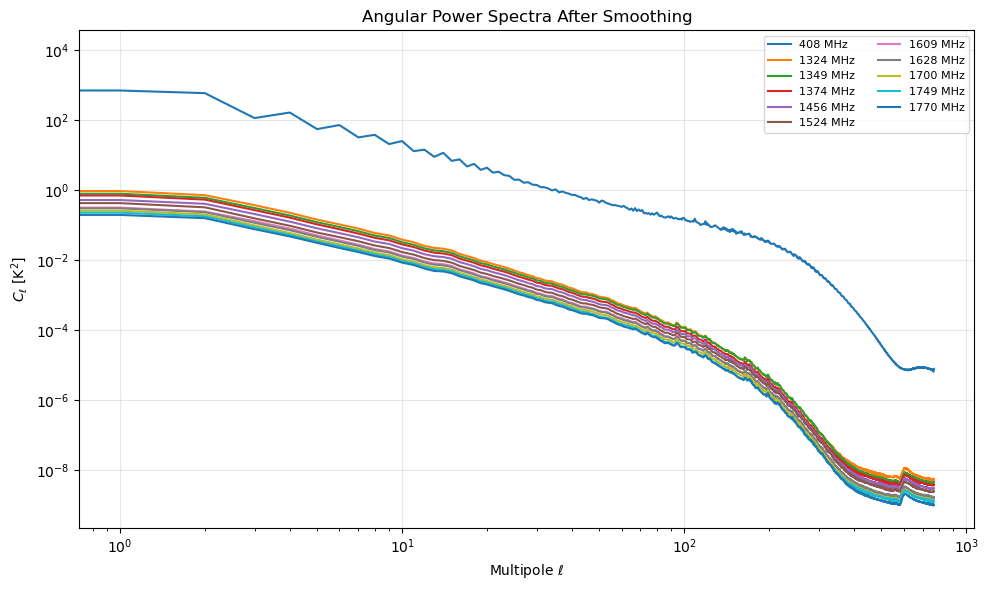

In [37]:
print(f"Frequencies loaded: {freqs}")

pl.figure(figsize=(10, 6))

for k in freqs:
    print(f"Computing C_ell for {k} MHz...")
    nans = np.ma.masked_invalid(maps[k]).mask
    tmp = maps[k].copy()
    tmp[nans] = hp.UNSEEN * maps[k].unit
    clt = hp.anafast(tmp)
    pl.loglog(clt, label=f'{k} MHz')

pl.xlabel(r'Multipole $\ell$')
pl.ylabel(r'$C_\ell$ [K$^2$]')
pl.title('Angular Power Spectra After Smoothing')
pl.legend(ncol=2, fontsize=8)
pl.grid(True, alpha=0.3)
pl.tight_layout()

### Power Spectrum Verification

Verify that all maps have been smoothed to the same resolution by checking their angular power spectra $C_\ell$. After smoothing, all maps should show similar high-$\ell$ suppression consistent with a 1° beam.

## 4. Noise and Calibration Uncertainties

### Error Model

Map uncertainties include contributions from:
1. **Instrumental noise**: Thermal noise from the receiver
2. **Calibration errors**: Systematic uncertainty in absolute temperature scale

### STAPS Noise Model

Following Figure 7 of [Basu et al. 2025](https://www.aanda.org/articles/aa/pdf/2025/02/aa53326-24.pdf), we adopt a linear interpolation for STAPS noise levels:

- 1324 MHz: $\sigma \approx 16$ mK
- 1770 MHz: $\sigma \approx 8$ mK

### 408 MHz Uncertainty

From [Remazeilles et al. 2015](https://arxiv.org/pdf/1411.3628), the instrumental noise is $\sigma_{\rm destr} \approx 0.1$ K.

In [38]:
# Compute noise levels for each frequency channel
errors = {}

# STAPS noise model: linear interpolation from 16 mK to 8 mK
x1 = min(freqs[freqs > 1000])
x2 = max(freqs[freqs > 1000])
y1 = 16 * u.mK
y2 = 8 * u.mK

stapsnoise = lambda f: y1 + (y2 - y1) * ((f - x1) / (x2 - x1))

for freq, m in maps.items():
    if freq > 1000:
        errors[freq] = stapsnoise(freq).to(u.K)

# 408 MHz noise from Remazeilles et al.
errors[408] = 0.1 * u.K

# Store errors for output
storerrors = {}
for f in maps.keys():
    storerrors[str(f)] = errors[f].value

# Save error dictionary
output_path = "../southern_data/fine_south_errors_dict.npz"
np.savez(output_path, **storerrors)
print(f"Saved error estimates to {output_path}\n")

# Print summary table
print("Per-frequency noise estimates:")
print("-" * 35)
for k in sorted(maps.keys()):
    print(f"  {k:5d} MHz:  σ = {storerrors[str(k)]:.4f} K")

Saved error estimates to ../southern_data/fine_south_errors_dict.npz

Per-frequency noise estimates:
-----------------------------------
    408 MHz:  σ = 0.1000 K
   1324 MHz:  σ = 0.0160 K
   1349 MHz:  σ = 0.0156 K
   1374 MHz:  σ = 0.0151 K
   1456 MHz:  σ = 0.0136 K
   1524 MHz:  σ = 0.0124 K
   1609 MHz:  σ = 0.0109 K
   1628 MHz:  σ = 0.0105 K
   1700 MHz:  σ = 0.0093 K
   1749 MHz:  σ = 0.0084 K
   1770 MHz:  σ = 0.0080 K


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_24874/2402409965.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


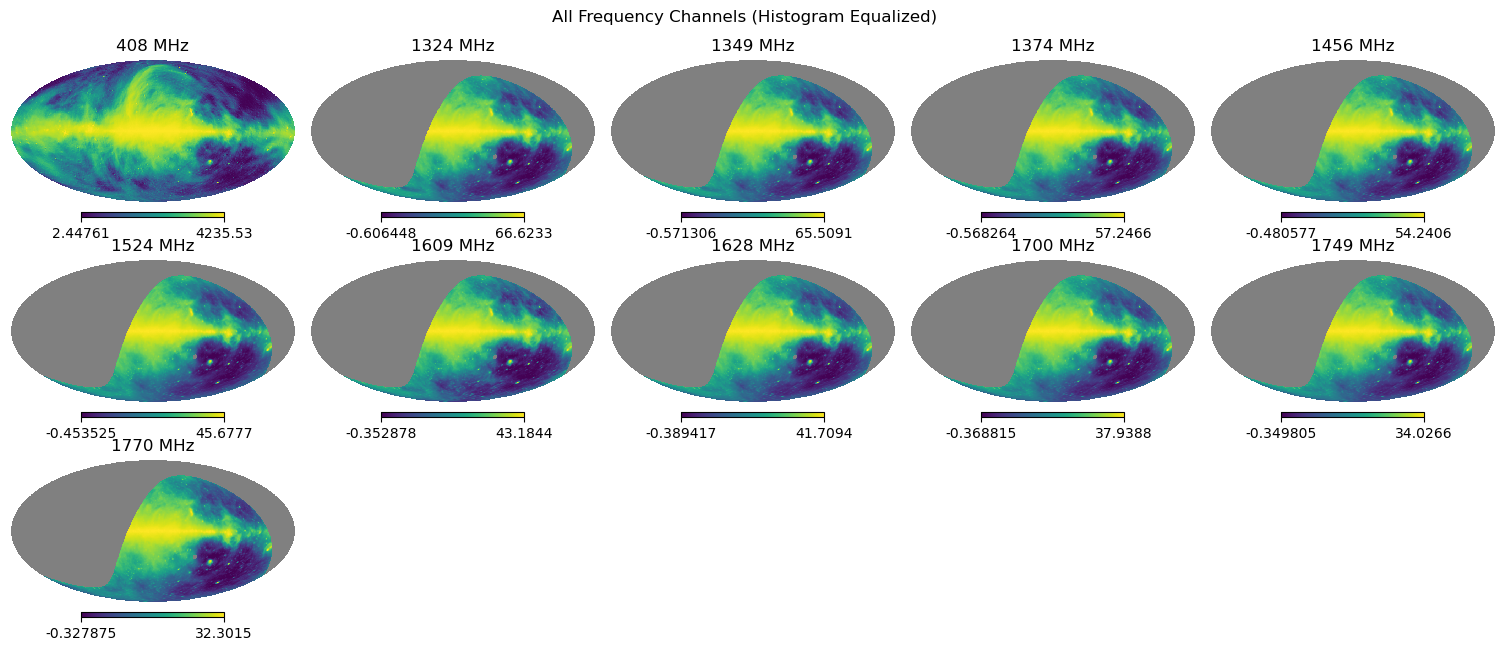

In [39]:
pl.figure(figsize=(15, 10))

for j, (freq, m) in enumerate(maps.items()):
    hp.mollview(
        m.value, 
        title=f'{freq} MHz', 
        sub=(5, 5, 1 + j), 
        notext=True, 
        norm='hist'
    )

pl.suptitle('All Frequency Channels (Histogram Equalized)', y=1.02)
pl.tight_layout()

### Map Gallery (Before Offset Removal)

Visual inspection of all frequency channels after smoothing but before offset correction. The histogram equalization (`norm='hist'`) helps visualize the dynamic range.

## 5. Zero-Level Offset Removal

### Methodology

Radio continuum surveys often suffer from uncertain zero-levels due to:
- Unknown contribution from the CMB monopole
- Variations in ground spillover during observations
- Baseline drifts in total-power measurements

We estimate and remove offsets by correlating each map with the 408 MHz reference:

$$T(\nu) = a \cdot T_{408} + c$$

The intercept $c$ represents the zero-level offset. We use **Orthogonal Distance Regression** (ODR) to account for uncertainties in both variables.

### Algorithm

1. Divide the sky into coarse superpixels ($N_{\rm side}=8$, ~7° patches)
2. Fit a linear relation in each superpixel
3. Accept only patches with strong correlation ($r > 0.75$) to avoid contamination from point sources
4. Compute the **median** offset across valid patches
5. Subtract the global offset from the map

In [40]:
# we have already estiamated the offsets at 5 degree resolution, just need to read those in
file = open("../outputs/offset_coarse_south.txt")
oldk = []
c_off = []
c_err  = []

for line in file:
    values = line.strip().split()
    oldk.append(float(values[0]))
    c_off.append(float(values[1]))
    c_err.append(float(values[2]))

off11 = np.asarray(c_off)
err11 = np.asarray(c_err)
oldk = np.asarray(oldk)

offerr = {}      # Offset uncertainties
off_map = {}     # Spatial offset maps
offsetvals = {}  # Estimated offset values

# Apply offset removal to all maps except the reference
print("Estimating and removing zero-level offsets...")
print("-" * 60)

for k in maps.keys():
    if k == 408:
        continue  # Skip reference map

    theval = np.where(oldk == k)[0][0]
    maps[k] = (maps[k].value - off11[theval])*maps[k].unit
    offsetvals[k] = off11[theval]
    offerr[k] = err11[theval]
    off_map[k] = np.zeros_like(maps[k].value) + off11[theval]

    print(f"  {k:5d} MHz:  offset = {offsetvals[k]:+8.4f}  ±  {offerr[k]:.4f}")

print("-" * 60)
print("Offset removal complete.")

Estimating and removing zero-level offsets...
------------------------------------------------------------
   1324 MHz:  offset =  -0.8308  ±  0.0196
   1349 MHz:  offset =  -0.7735  ±  0.0166
   1374 MHz:  offset =  -0.7309  ±  0.0154
   1456 MHz:  offset =  -0.6349  ±  0.0144
   1524 MHz:  offset =  -0.5732  ±  0.0134
   1609 MHz:  offset =  -0.4867  ±  0.0115
   1628 MHz:  offset =  -0.4914  ±  0.0122
   1700 MHz:  offset =  -0.4499  ±  0.0117
   1749 MHz:  offset =  -0.4317  ±  0.0106
   1770 MHz:  offset =  -0.4069  ±  0.0106
------------------------------------------------------------
Offset removal complete.


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_24874/4090402601.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


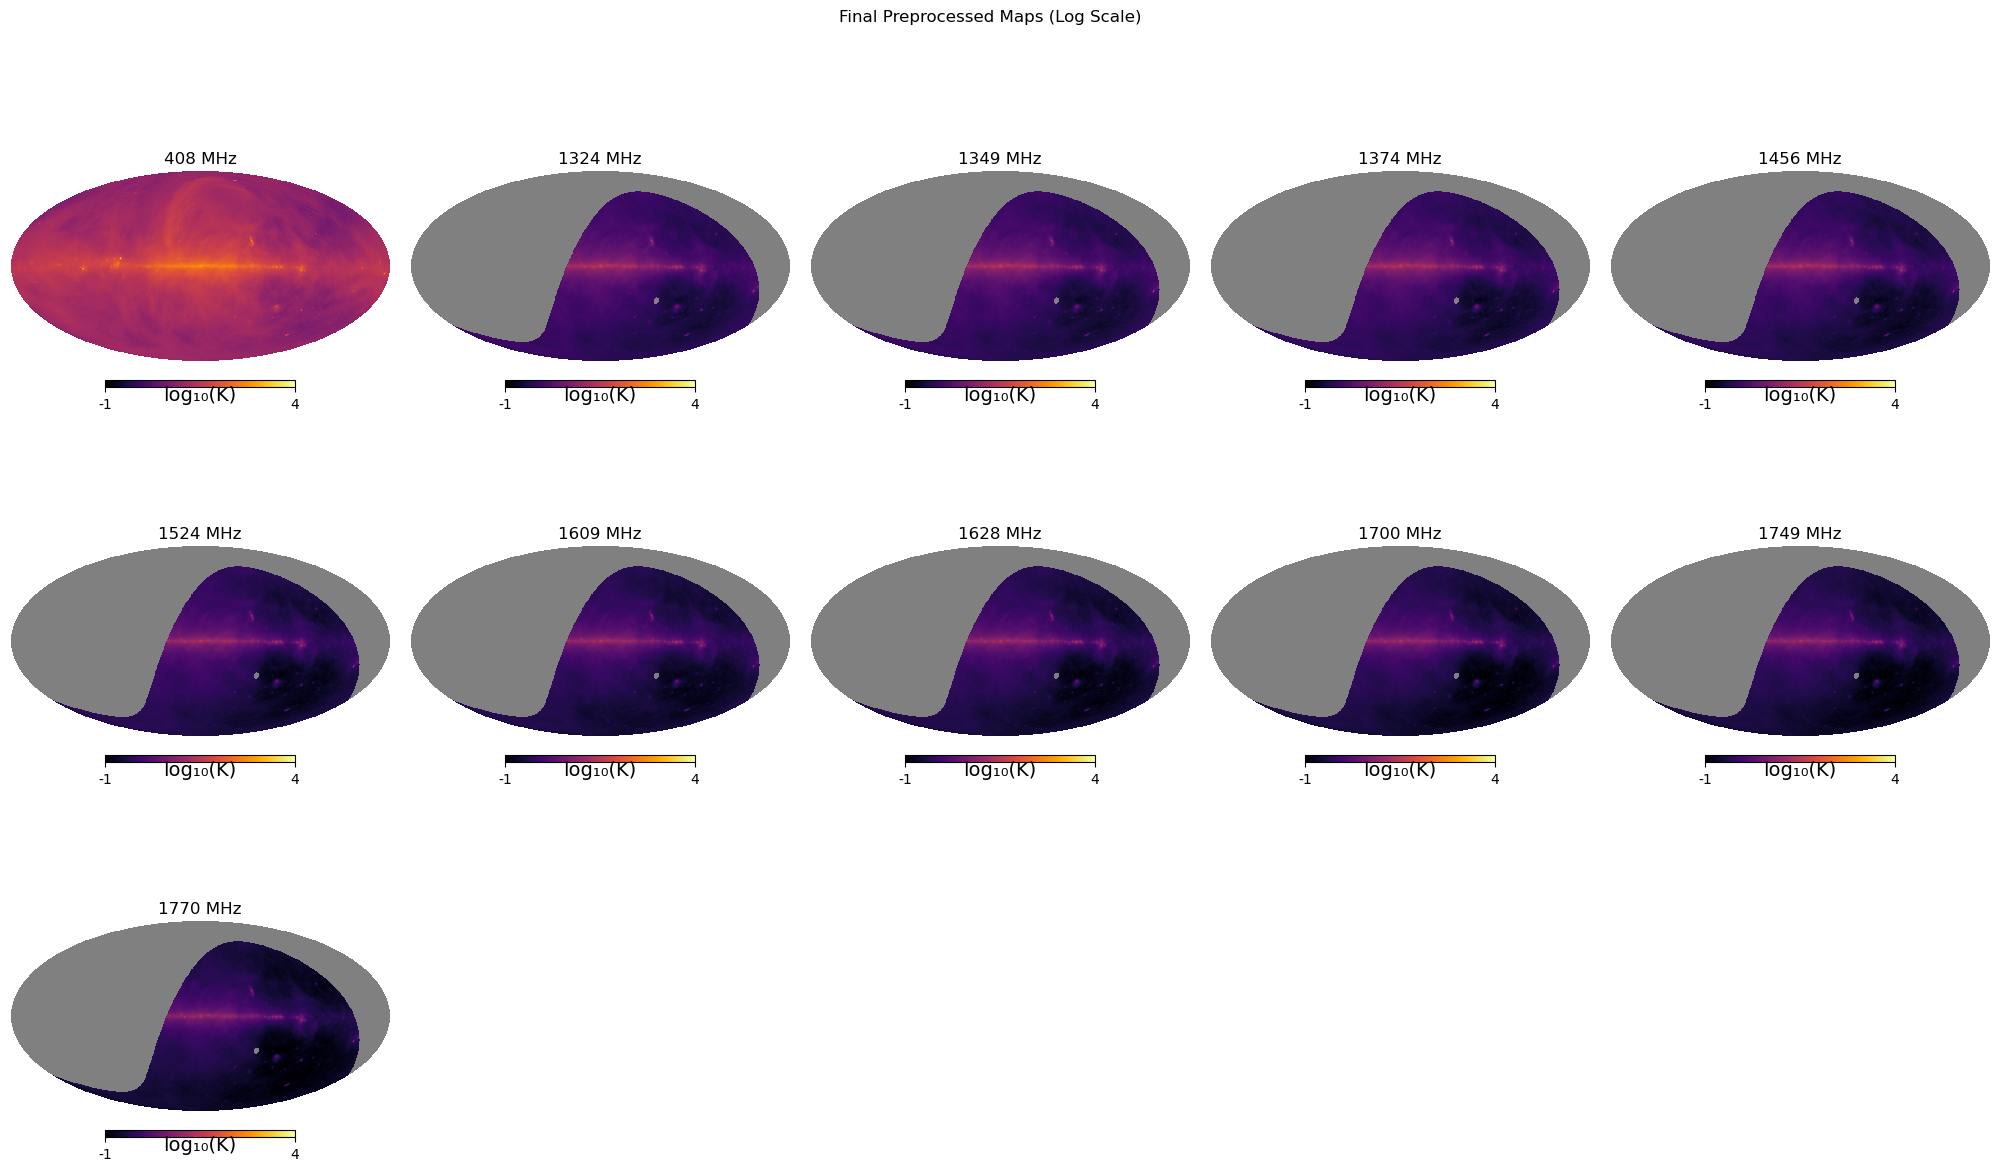

In [41]:
pl.figure(figsize=(20, 15))

for j, (freq, m) in enumerate(maps.items()):
    hp.mollview(
        np.log10(m.value), 
        title=f'{freq} MHz', 
        sub=(4, 5, 1 + j), 
        notext=True, 
        min=-1, 
        max=4, 
        unit=f'log₁₀({m.unit})', 
        cmap='inferno'
    )

pl.suptitle('Final Preprocessed Maps (Log Scale)', y=1.02)
pl.tight_layout()

### Final Maps Gallery

Visualization of all preprocessed maps in log scale (after offset removal). The dynamic range spans from ~1 K (cold regions) to ~10,000 K (Galactic center).

In [43]:
from astropy.table import Table

# Create Astropy Table with frequency channels as columns
t = Table(
    [m for m in maps.values()], 
    names=[str(freq) for freq in maps.keys()]
)

# Save to FITS
output_path = f'../southern_data/fine_south_maps_nside{nside}.fits'
t.write(output_path, format='fits', overwrite=True)

print(f"Saved preprocessed maps to: {output_path}")
print(f"  - Nside: {nside}")
print(f"  - Resolution: {fwhmax.to(u.deg):.2f}")
print(f"  - Frequencies: {sorted(maps.keys())} MHz")
print(f"  - Columns: {t.colnames}")

Saved preprocessed maps to: ../southern_data/fine_south_maps_nside256.fits
  - Nside: 256
  - Resolution: 1.00 deg
  - Frequencies: [408, 1324, 1349, 1374, 1456, 1524, 1609, 1628, 1700, 1749, 1770] MHz
  - Columns: ['408', '1324', '1349', '1374', '1456', '1524', '1609', '1628', '1700', '1749', '1770']


## 6. Save Output Products

Export the preprocessed maps as a single FITS file for downstream spectral analysis. The file contains one column per frequency channel, stored as an Astropy Table for easy metadata handling.

## Summary

This notebook has preprocessed southern hemisphere radio maps for synchrotron spectral analysis:

**Outputs produced:**
 - `fine_south_maps_nside256.fits` — Multi-frequency HEALPix maps at 1° resolution
 - `fine_south_errors_dict.npz` — Per-frequency instrumental noise estimates

 **Next steps:**
 - Use these maps as input to the spectral fitting pipeline (`fgbuster_fitting.py`)
 - The spectral index and curvature analysis requires fitting across all frequency channels simultaneously